In [1]:
from google.colab import files

uploaded = files.upload()


Saving StudentsPerformance.csv to StudentsPerformance.csv


In [2]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1000, 8)

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
print("=== DATA TYPES & NULL CHECK ===")
print(df.info())

print("\n=== SCORE STATISTICS ===")
print(df.describe())

=== DATA TYPES & NULL CHECK ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

=== SCORE STATISTICS ===
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000  

In [4]:
prep = df.groupby("test preparation course")[["math score",
                                              "reading score",
                                              "writing score"]].mean().round(1)
print(prep)

                         math score  reading score  writing score
test preparation course                                          
completed                      69.7           73.9           74.4
none                           64.1           66.5           64.5


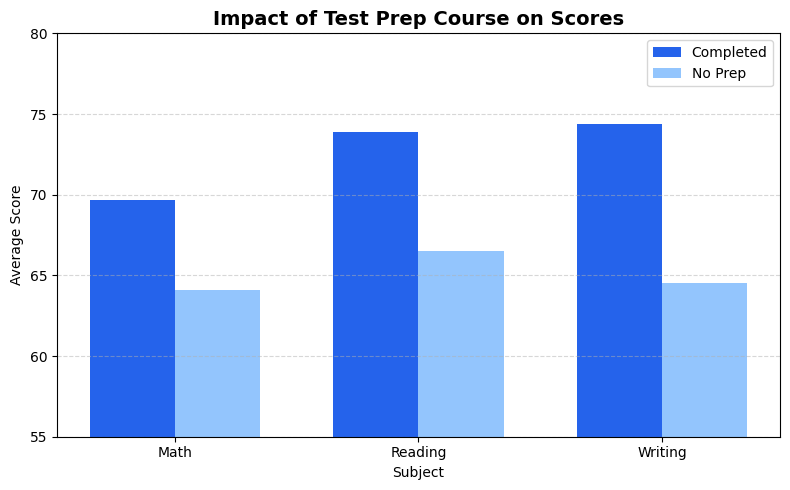

In [5]:
import matplotlib.pyplot as plt

# Data to plot
subjects = ["Math", "Reading", "Writing"]
completed = [69.7, 73.9, 74.4]
none = [64.1, 66.5, 64.5]

# Chart setup
x = range(len(subjects))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bar1 = ax.bar(x, completed, width, label="Completed", color="#2563EB")
bar2 = ax.bar([i + width for i in x], none, width, label="No Prep", color="#93C5FD")

# Labels and formatting
ax.set_title("Impact of Test Prep Course on Scores", fontsize=14, fontweight="bold")
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_xticks([i + width/2 for i in x])
ax.set_xticklabels(subjects)
ax.set_ylim(55, 80)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:
# Define the correct order from lowest to highest education
edu_order = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

edu = df.groupby("parental level of education")[["math score",
                                                  "reading score",
                                                  "writing score"]].mean().round(1)

# Reorder rows from lowest to highest education
edu = edu.reindex(edu_order)
print(edu)

                             math score  reading score  writing score
parental level of education                                          
some high school                   63.5           66.9           64.9
high school                        62.1           64.7           62.4
some college                       67.1           69.5           68.8
associate's degree                 67.9           70.9           69.9
bachelor's degree                  69.4           73.0           73.4
master's degree                    69.7           75.4           75.7


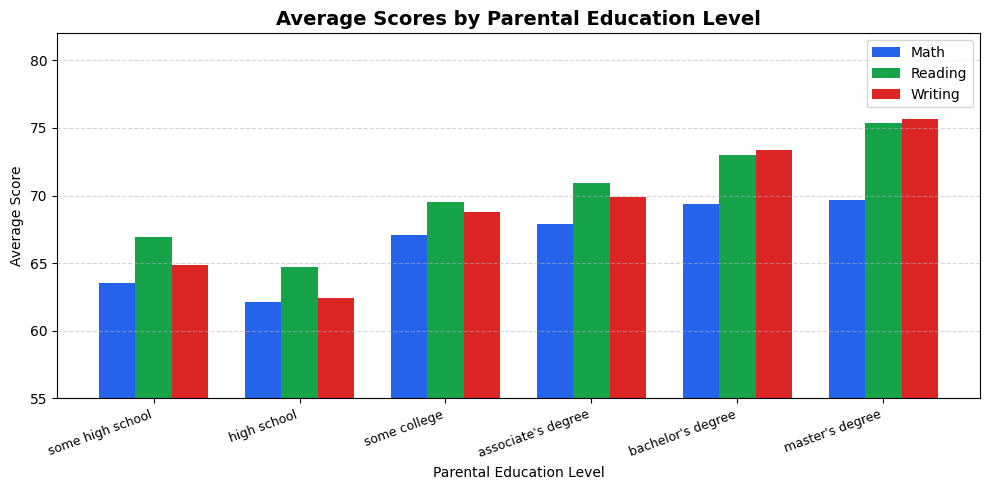

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(edu_order))
width = 0.25

bar1 = ax.bar(x, edu["math score"], width, label="Math", color="#2563EB")
bar2 = ax.bar([i + width for i in x], edu["reading score"], width,
               label="Reading", color="#16A34A")
bar3 = ax.bar([i + width*2 for i in x], edu["writing score"], width,
               label="Writing", color="#DC2626")

ax.set_title("Average Scores by Parental Education Level",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Parental Education Level")
ax.set_ylabel("Average Score")
ax.set_xticks([i + width for i in x])
ax.set_xticklabels(edu_order, rotation=20, ha="right", fontsize=9)
ax.set_ylim(55, 82)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [8]:
gender = df.groupby("gender")[["math score",
                                "reading score",
                                "writing score"]].mean().round(1)
print(gender)

        math score  reading score  writing score
gender                                          
female        63.6           72.6           72.5
male          68.7           65.5           63.3


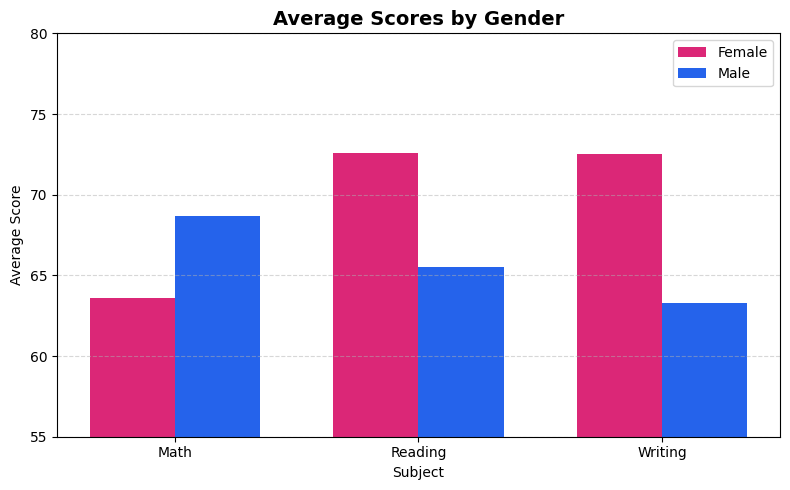

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

subjects = ["Math", "Reading", "Writing"]
female_scores = [63.6, 72.6, 72.5]
male_scores = [68.7, 65.5, 63.3]

x = range(len(subjects))
width = 0.35

ax.bar(x, female_scores, width, label="Female", color="#DB2777")
ax.bar([i + width for i in x], male_scores, width, label="Male", color="#2563EB")

ax.set_title("Average Scores by Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_xticks([i + width/2 for i in x])
ax.set_xticklabels(subjects)
ax.set_ylim(55, 80)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
summary = """
==============================================
   STUDENT PERFORMANCE ANALYSIS — FINDINGS
==============================================

Dataset: 1000 students | 8 variables | 0 missing values

FINDING 1 — Test Preparation Course
-------------------------------------
Students who completed the prep course scored higher across
all three subjects. The biggest impact was in writing (+9.9 points),
followed by reading (+7.4) and math (+5.6).
Conclusion: Prep courses have a meaningful positive effect on performance.

FINDING 2 — Parental Education Level
--------------------------------------
A clear positive correlation exists between parental education
and student scores. Students with parents holding a master's degree
scored up to 10.8 points higher in writing than students whose
parents didn't finish high school.
Conclusion: Higher parental education is linked to better student outcomes.

FINDING 3 — Gender
--------------------
Male students scored higher in math (68.7 vs 63.6, +5.1 points).
Female students scored higher in reading (+7.1) and writing (+9.2).
Overall, female students performed stronger across the majority of subjects.
Conclusion: Gender differences exist per subject but females lead overall.

==============================================
Tools used: Python, pandas, matplotlib
Certificate applied: Google Data Analytics (Coursera)
==============================================
"""

print(summary)


   STUDENT PERFORMANCE ANALYSIS — FINDINGS

Dataset: 1000 students | 8 variables | 0 missing values

FINDING 1 — Test Preparation Course
-------------------------------------
Students who completed the prep course scored higher across
all three subjects. The biggest impact was in writing (+9.9 points),
followed by reading (+7.4) and math (+5.6).
Conclusion: Prep courses have a meaningful positive effect on performance.

FINDING 2 — Parental Education Level
--------------------------------------
A clear positive correlation exists between parental education
and student scores. Students with parents holding a master's degree
scored up to 10.8 points higher in writing than students whose
parents didn't finish high school.
Conclusion: Higher parental education is linked to better student outcomes.

FINDING 3 — Gender
--------------------
Male students scored higher in math (68.7 vs 63.6, +5.1 points).
Female students scored higher in reading (+7.1) and writing (+9.2).
Overall, female stud